In [9]:
import numpy as np
import moments 
import matplotlib.pyplot as plt 
import matplotlib 
import scipy
import demes 
import demesdraw
import string
from matplotlib.transforms import ScaledTranslation

In [32]:
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}\usepackage{amssymb}"
#matplotlib.rcParams['font.family'] = "serif"
#matplotlib.rcParams['font.serif'] = "Computer Modern"
matplotlib.rcParams['savefig.bbox'] = "tight"
#matplotlib.rcParams['axes.linewidth'] = 0.5
#lw = 0.8
lw = 1

In [11]:
def make_covariance_plot(ax):
    # plot the genealogical covariance Cov(Tl, Tr) at equilibrium
    N = 1e4
    rhos = np.logspace(np.log10(1e-7 * 4 * N), np.log10(1e-2 * 4 * N), 100)
    covs = (rhos + 18) / (rhos ** 2 + 13 * rhos + 18)
    ax.plot(rhos, covs, color="black", lw=lw)
    ax.set_xscale("log")
    ax.set_ylabel(r"$\operatorname{Cov}(T_L, T_R)$")
    ax.set_xlabel(r"$\rho$")
    ax.set_ylim(0, )
    ax.minorticks_off()
    return

In [12]:
def make_equil_expectation_plot(ax):
    N = 1e4
    u = 1e-8
    rhos = np.logspace(np.log10(1e-7 * 4 * N), np.log10(1e-2 * 4 * N), 100)

    theta = 4 * u * N
    yy = moments.LD.Demographics1D.snm(rho=rhos, theta=theta)
    dp = yy.H2(0)
    ax.plot(rhos, dp, color="black", lw=lw)
    ax.set_xscale("log")
    ax.set_ylabel(r"$\mathbb{E}[D^+]$")
    ax.set_xlabel(r"$\rho$")
    ax.set_yticks([theta ** 2, 2 * theta ** 2], [r"$\theta^2$", r"$2\theta^2$"])
    ax.minorticks_off()
    return

In [ ]:
def get_introgression_model(p, T):
    builder = demes.Builder()
    builder.add_deme("X", epochs=[{"start_size": 1e4, "end_time": 0}])
    builder.add_deme("Y", start_time=2e4 + T, ancestors=["X"],
        epochs=[{"start_size": 1e4, "end_time": T}])
    builder.add_pulse(sources=["Y"], dest="X", time=T, proportions=[p])
    graph = builder.resolve()
    return graph


def make_introgression_model_plot(ax):
    graph = get_introgression_model(0.10, 500)
    demesdraw.tubes(graph, ax=ax, labels="xticks", fill=True, colours="gainsboro")
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    ax.set_ylabel("$t$ (generations ago)")
    return

def make_introgression_plot(ax):
    inset = ax.inset_axes([0.58, 0.61, 0.38, 0.35])
    graph = get_introgression_model(0.10, 5000)
    demesdraw.tubes(graph, ax=inset, labels=None, colours="tab:blue", 
                    inf_ratio=0.10, positions={"X": 0, "Y": 2e4})
    inset.spines["top"].set_visible(True)
    inset.spines["right"].set_visible(True)
    inset.spines["bottom"].set_visible(True)
    inset.set_ylabel("$t$")
    inset.set_yticks([0, 5000, 25000], [0, r"$\tau$", r"$\tau + 1$"])

    u = 1e-8
    rs = np.logspace(-6, -2, 100)
    rhos = 1e4 * 4 * rs

    yy = moments.Demes.LD(
        get_introgression_model(0.0, 100), sampled_demes=["X"], u=u, r=rs)
    dp = yy.H2(0)
    ax.plot(rhos, dp / yy.H() ** 2, color="black", lw=lw)
    ax.annotate(r"$\tau<0$", (4e-2, 1.83), color="black")

    yy = moments.Demes.LD(
        get_introgression_model(0.10, 1), sampled_demes=["X"], u=u, r=rs)
    dp = yy.H2(0)
    ax.plot(rhos, dp / yy.H() ** 2, color="tab:blue", lw=lw)
    ax.annotate(r"$\tau=0$", (4e-2, 1.6), color="tab:blue")

    yy = moments.Demes.LD(
        get_introgression_model(0.10, 400), sampled_demes=["X"], u=u, r=rs)
    dp = yy.H2(0)
    ax.plot(rhos, dp / yy.H() ** 2, color="tab:orange", lw=lw)
    ax.annotate(r"$\tau=0.02$", (4e-2, 1.5), color="tab:orange")

    ax.set_xscale("log")
    ax.set_ylabel(r"$\mathbb{E}[D^+] / \mathbb{E}[\pi]^2$")
    ax.set_xlabel(r"$\rho$")
    ax.set_yticks([1, 2])
    ax.minorticks_off()
    return

In [29]:
def make_growth_plot(ax):
    inset = ax.inset_axes([0.61, 0.61, 0.35, 0.35])
    inset.step([0, 1, 1.5], [10, 10, 1], color="black")
    inset.set_xticks([1, 0], [r"$\tau$", 0])
    inset.set_ylabel(r"$\nu(t)$")
    inset.set_xlabel("t")
    inset.set_xlim(0, 1.5)
    inset.set_yscale("log")
    inset.set_yticks([1, 10], [1, 10])
    inset.minorticks_off()

    theta = 4 * 1e-8 * 1e4
    rs = np.logspace(-6, -2, 100)
    rhos = 4 * rs * 1e4

    yy0 = moments.LD.Demographics1D.snm(rho=rhos, theta=theta)
    dp0 = yy0.H2(0)
    ax.plot(rhos, dp0 / yy0.H() ** 2, color="black", lw=lw)
    ax.annotate(r"$\tau=0$", (4e-2, 1.81))

    yy = moments.LD.Demographics1D.two_epoch([10, 2], rho=rhos, theta=theta)
    dp = yy.H2(0)
    ax.plot(rhos, dp / yy.H() ** 2, color="tab:blue", lw=lw)
    ax.annotate(r"$\tau=2$", (4e-2, 1.05), color="tab:blue")

    yy = moments.LD.Demographics1D.two_epoch([10, 100], rho=rhos, theta=theta)
    dp = yy.H2(0)
    ax.plot(rhos, dp / yy.H() ** 2, color="tab:orange", lw=lw)
    ax.annotate(r"$\tau=\infty$", (4e-2, 1.25), color="tab:orange")

    ax.set_xscale("log")
    ax.set_ylabel(r"$\mathbb{E}[D^+] / \mathbb{E}[\pi]^2$")
    ax.set_xlabel(r"$\rho$")
    ax.set_yticks([1, 2])
    ax.minorticks_off()
    return


def make_contraction_plot(ax):
    inset = ax.inset_axes([0.61, 0.61, 0.35, 0.35])
    inset.step([0, 1, 1.5], [0.1, 0.1, 1], color="black", label="growth")
    inset.set_xticks([1, 0], [r"$\tau$", 0])
    inset.set_ylabel(r"$\nu(t)$")
    inset.set_xlabel("t")
    inset.set_xlim(0, 1.5)
    inset.set_yscale("log")
    inset.set_yticks([0.1, 1], [0.1, 1])
    inset.minorticks_off()

    theta = 4 * 1e-8 * 1e4
    rs = np.logspace(-6, -2, 100)
    rhos = 4 * rs * 1e4

    yy0 = moments.LD.Demographics1D.snm(rho=rhos, theta=theta)
    dp0 = yy0.H2(0)
    ax.plot(rhos, dp0 / yy0.H() ** 2, color="black", lw=lw)
    ax.annotate(r"$\tau=0$", (4e-2, 1.4))

    yy = moments.LD.Demographics1D.two_epoch([0.1, 0.2], rho=rhos, theta=theta)
    dp = yy.H2(0)
    ax.plot(rhos, dp / yy.H() ** 2, color="tab:blue", lw=lw)
    ax.annotate(r"$\tau=0.2$", (4e-2, 5.5), color="tab:blue")

    yy = moments.LD.Demographics1D.two_epoch([0.1, 5], rho=rhos, theta=theta)
    dp = yy.H2(0)
    ax.plot(rhos, dp / yy.H() ** 2, color="tab:orange", lw=lw)
    ax.annotate(r"$\tau=\infty$", (4e-2, 2.4), color="tab:orange")


    ax.set_xscale("log")
    ax.set_ylabel(r"$\mathbb{E}[D^+] / \mathbb{E}[\pi]^2$")
    ax.set_xlabel(r"$\rho$")
    ax.minorticks_off()
    return

In [30]:
def make_island_plot(ax):
    inset = ax.inset_axes([0.58, 0.61, 0.38, 0.35])
    builder = demes.Builder()
    builder.add_deme("A", epochs=[{"start_size": 1000, "end_time": 0}])
    builder.add_deme("B", epochs=[{"start_size": 1000, "end_time": 0}])
    builder.add_migration(rate=1e-4, demes=["A", "B"])
    graph = builder.resolve()
    demesdraw.tubes(graph, ax=inset, colours="tab:blue", labels=None, 
                    num_lines_per_migration=4, positions={"A": 0, "B": 2e3})
    inset.spines["top"].set_visible(True)
    inset.spines["right"].set_visible(True)
    inset.spines["bottom"].set_visible(True)
    inset.set_ylabel("$t$")
    inset.set_yticks([0])

    theta = 4 * 1e-8 * 1e4
    rs = np.logspace(-6, -2, 100)
    rhos = 4 * rs * 1e4

    yy = moments.LD.Demographics2D.island_model([0.5, 0.5, 50, 50], rho=rhos, theta=theta)
    dp = yy.H2(0)
    ax.plot(rhos, dp / yy.H()[0] ** 2, color="black", lw=lw)
    ax.annotate("$M=100$", (4e-2, 1.6), color="black")

    yy = moments.LD.Demographics2D.island_model([0.5, 0.5, 2.5, 2.5], rho=rhos, theta=theta)
    dp = yy.H2(0)
    ax.plot(rhos, dp / yy.H()[0] ** 2, color="tab:blue", lw=lw)
    ax.annotate("$M=5$", (4e-2, 2.25), color="tab:blue")

    yy = moments.LD.Demographics2D.island_model([0.5, 0.5, 0.5, 0.5], rho=rhos, theta=theta)
    dp = yy.H2(0)
    ax.plot(rhos, dp / yy.H()[0] ** 2, color="tab:orange", lw=lw)
    ax.annotate("$M=1$", (4e-2, 2.6), color="tab:orange")


    ax.set_xscale("log")
    ax.set_ylabel(r"$\mathbb{E}[D^+] / \mathbb{E}[\pi]^2$")
    ax.set_xlabel(r"$\rho$")
    ax.set_yticks([1, 2, 3])
    ax.minorticks_off()
    return

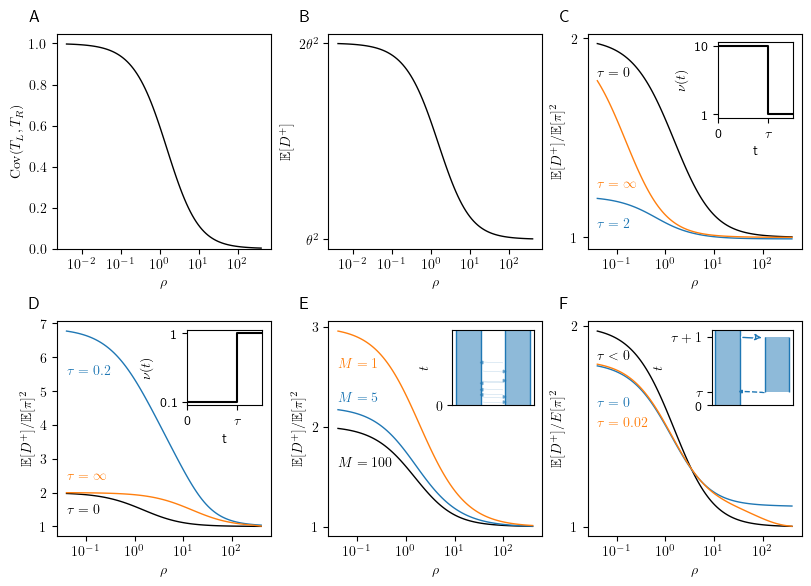

In [33]:
mosaic = "ABC;DEF"
fig, axs = plt.subplot_mosaic(mosaic, figsize=(8, 5.75), layout="constrained")
for label, ax in axs.items():
    ax.text(0.0, 1.0, label, fontsize="large", va="bottom", transform=(
        ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)))
make_covariance_plot(axs["A"])
make_equil_expectation_plot(axs["B"])
make_growth_plot(axs["C"])
make_contraction_plot(axs["D"])
make_island_plot(axs["E"])
make_introgression_plot(axs["F"])
#plt.savefig("figures/fig1.pdf")

In [17]:
"""fig, ax = plt.subplots(figsize=(2.7, 2.5))    

N = 1e4
u = 1e-8
rhos = np.logspace(np.log10(1e-7 * 4 * N), np.log10(1e-2 * 4 * N), 100)

theta = 4 * u * N
yy = moments.LD.Demographics1D.snm(rho=rhos, theta=theta)
dp = yy.H2(0)
ax.plot(rhos, dp, color="black", lw=lw)
ax.set_xscale("log")
ax.set_ylabel(r"$\mathbb{E}[D^+]$")
ax.set_xlabel(r"$\rho$")
ax.set_yticks([theta ** 2, 2 * theta ** 2], [r"$\theta^2$", r"$2\theta^2$"])
ax.minorticks_off()"""

<>:1: DeprecationWarning: invalid escape sequence '\m'


'fig, ax = plt.subplots(figsize=(2.7, 2.5))    \n\nN = 1e4\nu = 1e-8\nrhos = np.logspace(np.log10(1e-7 * 4 * N), np.log10(1e-2 * 4 * N), 100)\n\ntheta = 4 * u * N\nyy = moments.LD.Demographics1D.snm(rho=rhos, theta=theta)\ndp = yy.H2(0)\nax.plot(rhos, dp, color="black", lw=lw)\nax.set_xscale("log")\nax.set_ylabel(r"$\\mathbb{E}[D^+]$")\nax.set_xlabel(r"$\rho$")\nax.set_yticks([theta ** 2, 2 * theta ** 2], [r"$\theta^2$", r"$2\theta^2$"])\nax.minorticks_off()'

In [18]:
"""fig, ax = plt.subplots(figsize=(2.7, 2.5))
inset = ax.inset_axes([0.55, 0.55, 0.4, 0.4])

theta = 4 * 1e-8 * 1e4
rs = np.logspace(-6, -2, 100)
rhos = 4 * rs * 1e4

yy0 = moments.LD.Demographics1D.snm(rho=rhos, theta=theta)
dp0 = yy0.H2(0)
ax.plot(rs, dp0 / yy0.H() ** 2, color="black")


yy = moments.LD.Demographics1D.two_epoch([10, 10], rho=rhos, theta=theta)
dp = yy.H2(0)
ax.plot(rs, dp / yy.H() ** 2, color="black", lw=0.75)


yy = moments.LD.Demographics1D.two_epoch([10, 100], rho=rhos, theta=theta)
dp = yy.H2(0)
ax.plot(rs, dp / yy.H() ** 2, color="black", lw=0.75)

ax.set_xscale("log")
ax.set_ylabel(r"$\mathbb{E}[D^+] / \mathbb{E}[\pi]^2$")
ax.set_xlabel("$r$")

"""

'fig, ax = plt.subplots(figsize=(2.7, 2.5))\ninset = ax.inset_axes([0.55, 0.55, 0.4, 0.4])\n\ntheta = 4 * 1e-8 * 1e4\nrs = np.logspace(-6, -2, 100)\nrhos = 4 * rs * 1e4\n\nyy0 = moments.LD.Demographics1D.snm(rho=rhos, theta=theta)\ndp0 = yy0.H2(0)\nax.plot(rs, dp0 / yy0.H() ** 2, color="black")\n\n\nyy = moments.LD.Demographics1D.two_epoch([10, 10], rho=rhos, theta=theta)\ndp = yy.H2(0)\nax.plot(rs, dp / yy.H() ** 2, color="black", lw=0.75)\n\n\nyy = moments.LD.Demographics1D.two_epoch([10, 100], rho=rhos, theta=theta)\ndp = yy.H2(0)\nax.plot(rs, dp / yy.H() ** 2, color="black", lw=0.75)\n\nax.set_xscale("log")\nax.set_ylabel(r"$\\mathbb{E}[D^+] / \\mathbb{E}[\\pi]^2$")\nax.set_xlabel("$r$")\n\n'

In [19]:
"""fig, ax = plt.subplots(figsize=(3, 2.7))
inset = ax.inset_axes([0.65, 0.55, 0.3, 0.4])

theta = 4 * 1e-8 * 1e4
rs = np.logspace(-6, -2, 100)
rhos = 4 * rs * 1e4

yy0 = moments.LD.Demographics1D.snm(rho=rhos, theta=theta)
dp0 = yy0.H2(0)
ax.plot(rs, dp0 / yy0.H() ** 2, color="black")
ax.annotate("$t=0$", (1e-6, 1.4))

yy = moments.LD.Demographics1D.two_epoch([0.1, 0.25], rho=rhos, theta=theta)
dp = yy.H2(0)
ax.plot(rs, dp / yy.H() ** 2, color="black", lw=0.75)
ax.annotate("$t=2500$", (1e-6, 6))

yy = moments.LD.Demographics1D.two_epoch([0.1, 0.5], rho=rhos, theta=theta)
dp = yy.H2(0)
ax.plot(rs, dp / yy.H() ** 2, color="black", lw=0.75)
ax.annotate("$t=5000$", (1e-6, 3.8))

yy = moments.LD.Demographics1D.two_epoch([0.1, 5], rho=rhos, theta=theta)
dp = yy.H2(0)
ax.plot(rs, dp / yy.H() ** 2, color="black", lw=0.75)
ax.annotate(r"$t=\infty$", (1e-6, 2.4))


ax.set_xscale("log")
ax.set_ylabel(r"$\mathbb{E}[D^+] / \mathbb{E}[\pi]^2$")
ax.set_xlabel("$r$")

inset.step([0, 1, 1.5], [1e3, 1e3, 1e4], color="black", label="growth")
inset.set_xticks([1, 0], ["$t$", 0])
inset.set_ylabel("$N(t)$")
inset.set_xlabel("time")
inset.set_xlim(0, 1.5)
inset.set_yscale("log")
"""


<>:1: DeprecationWarning: invalid escape sequence '\i'


'fig, ax = plt.subplots(figsize=(3, 2.7))\ninset = ax.inset_axes([0.65, 0.55, 0.3, 0.4])\n\ntheta = 4 * 1e-8 * 1e4\nrs = np.logspace(-6, -2, 100)\nrhos = 4 * rs * 1e4\n\nyy0 = moments.LD.Demographics1D.snm(rho=rhos, theta=theta)\ndp0 = yy0.H2(0)\nax.plot(rs, dp0 / yy0.H() ** 2, color="black")\nax.annotate("$t=0$", (1e-6, 1.4))\n\nyy = moments.LD.Demographics1D.two_epoch([0.1, 0.25], rho=rhos, theta=theta)\ndp = yy.H2(0)\nax.plot(rs, dp / yy.H() ** 2, color="black", lw=0.75)\nax.annotate("$t=2500$", (1e-6, 6))\n\nyy = moments.LD.Demographics1D.two_epoch([0.1, 0.5], rho=rhos, theta=theta)\ndp = yy.H2(0)\nax.plot(rs, dp / yy.H() ** 2, color="black", lw=0.75)\nax.annotate("$t=5000$", (1e-6, 3.8))\n\nyy = moments.LD.Demographics1D.two_epoch([0.1, 5], rho=rhos, theta=theta)\ndp = yy.H2(0)\nax.plot(rs, dp / yy.H() ** 2, color="black", lw=0.75)\nax.annotate(r"$t=\\infty$", (1e-6, 2.4))\n\n\nax.set_xscale("log")\nax.set_ylabel(r"$\\mathbb{E}[D^+] / \\mathbb{E}[\\pi]^2$")\nax.set_xlabel("$r$")\n

In [20]:
"""fig, ax = plt.subplots(figsize=(3, 2.7))
inset = ax.inset_axes([0.58, 0.62, 0.39, 0.35])
builder = demes.Builder()
builder.add_deme("A", epochs=[{"start_size": 1000, "end_time": 0}])
builder.add_deme("B", epochs=[{"start_size": 1000, "end_time": 0}])
builder.add_migration(rate=1e-4, demes=["A", "B"])
graph = builder.resolve()
demesdraw.tubes(graph, ax=inset, colours="black", fill=False, labels=None)
inset.spines["top"].set_visible(True)
inset.spines["right"].set_visible(True)
inset.spines["bottom"].set_visible(True)
inset.set_ylabel("$t$")
inset.set_yticks([0])

theta = 4 * 1e-8 * 1e4
rs = np.logspace(-6, -2, 100)
rhos = 4 * rs * 1e4


yy = moments.LD.Demographics2D.island_model([0.5, 0.5, 50, 50], rho=rhos, theta=theta)
dp = yy.H2(0)
ax.plot(rs, dp / yy.H()[0] ** 2, color="black", lw=lw)
ax.annotate("$M=100$", (1e-6, 1.6), color="black")

yy = moments.LD.Demographics2D.island_model([0.5, 0.5, 2.5, 2.5], rho=rhos, theta=theta)
dp = yy.H2(0)
ax.plot(rs, dp / yy.H()[0] ** 2, color="tab:blue", lw=lw)
ax.annotate("$M=5$", (1e-6, 2.25), color="tab:blue")

yy = moments.LD.Demographics2D.island_model([0.5, 0.5, 0.5, 0.5], rho=rhos, theta=theta)
dp = yy.H2(0)
ax.plot(rs, dp / yy.H()[0] ** 2, color="tab:orange", lw=lw)
ax.annotate("$M=1$", (1e-6, 2.6), color="tab:orange")


ax.set_xscale("log")
ax.set_ylabel(r"$\mathbb{E}[D^+] / \mathbb{E}[\pi]^2$")
ax.set_xlabel("$r$")
"""

'fig, ax = plt.subplots(figsize=(3, 2.7))\ninset = ax.inset_axes([0.58, 0.62, 0.39, 0.35])\nbuilder = demes.Builder()\nbuilder.add_deme("A", epochs=[{"start_size": 1000, "end_time": 0}])\nbuilder.add_deme("B", epochs=[{"start_size": 1000, "end_time": 0}])\nbuilder.add_migration(rate=1e-4, demes=["A", "B"])\ngraph = builder.resolve()\ndemesdraw.tubes(graph, ax=inset, colours="black", fill=False, labels=None)\ninset.spines["top"].set_visible(True)\ninset.spines["right"].set_visible(True)\ninset.spines["bottom"].set_visible(True)\ninset.set_ylabel("$t$")\ninset.set_yticks([0])\n\ntheta = 4 * 1e-8 * 1e4\nrs = np.logspace(-6, -2, 100)\nrhos = 4 * rs * 1e4\n\n\nyy = moments.LD.Demographics2D.island_model([0.5, 0.5, 50, 50], rho=rhos, theta=theta)\ndp = yy.H2(0)\nax.plot(rs, dp / yy.H()[0] ** 2, color="black", lw=lw)\nax.annotate("$M=100$", (1e-6, 1.6), color="black")\n\nyy = moments.LD.Demographics2D.island_model([0.5, 0.5, 2.5, 2.5], rho=rhos, theta=theta)\ndp = yy.H2(0)\nax.plot(rs, dp / y

In [21]:
"""
fig, ax = plt.subplots(figsize=(3, 2.7))
inset = ax.inset_axes([0.62, 0.62, 0.35, 0.35])
builder = demes.Builder()
builder.add_deme("A", epochs=[{"start_size": 1000, "end_time": 0}])
builder.add_deme("B", epochs=[{"start_size": 1000, "end_time": 0}])
builder.add_migration(rate=1e-4, demes=["A", "B"])
graph = builder.resolve()
demesdraw.tubes(graph, ax=inset, colours="blue", labels=None)
inset.spines["top"].set_visible(True)
inset.spines["right"].set_visible(True)
inset.spines["bottom"].set_visible(True)
inset.set_ylabel("$t$")
inset.set_yticks([0])

N = 1e5
u = 1e-8
rs = np.logspace(-6, -2, 100)

theta = 4 * u * N
rhos = 4 * rs * N

yy0 = moments.LD.Demographics1D.snm(rho=rhos, theta=theta)
dp0 = yy0.H2(0)
ax.plot(rs, dp0 / yy0.H() ** 2, color="black", lw=lw)
ax.annotate("$M=0$", (1e-6, 1.5))

yy = moments.LD.Demographics2D.island_model([0.5, 0.5, 10, 10], rho=rhos, theta=theta)
dp = yy.H2(0)
ax.plot(rs, dp / yy.H()[0] ** 2, color="tab:blue", lw=lw)
# ax.annotate("$M=0.1$", (1e-6, 4.5))

yy = moments.LD.Demographics2D.island_model([0.5, 0.5, 5, 5], rho=rhos, theta=theta)
dp = yy.H2(0)
ax.plot(rs, dp / yy.H()[0] ** 2, color="tab:orange", lw=lw)
# ax.annotate("$M=0.1$", (1e-6, 4.5))

yy = moments.LD.Demographics2D.island_model([0.5, 0.5, 1, 1], rho=rhos, theta=theta)
dp = yy.H2(0)
ax.plot(rs, dp / yy.H()[0] ** 2, color="tab:green", lw=lw)
# ax.annotate("$M=0.1$", (1e-6, 4.5))

yy = moments.LD.Demographics2D.island_model([0.5, 0.5, 0.1, 0.1], rho=rhos, theta=theta)
dp = yy.H2(0)
ax.plot(rs, dp / yy.H()[0] ** 2, color="tab:red", lw=lw)
# ax.annotate("$M=0.1$", (1e-6, 4.5))

ax.set_xscale("log")
ax.set_ylabel(r"$\mathbb{E}[D^+] / \mathbb{E}[\pi]^2$")
ax.set_xlabel("$r$")
"""

'\nfig, ax = plt.subplots(figsize=(3, 2.7))\ninset = ax.inset_axes([0.62, 0.62, 0.35, 0.35])\nbuilder = demes.Builder()\nbuilder.add_deme("A", epochs=[{"start_size": 1000, "end_time": 0}])\nbuilder.add_deme("B", epochs=[{"start_size": 1000, "end_time": 0}])\nbuilder.add_migration(rate=1e-4, demes=["A", "B"])\ngraph = builder.resolve()\ndemesdraw.tubes(graph, ax=inset, colours="blue", labels=None)\ninset.spines["top"].set_visible(True)\ninset.spines["right"].set_visible(True)\ninset.spines["bottom"].set_visible(True)\ninset.set_ylabel("$t$")\ninset.set_yticks([0])\n\nN = 1e5\nu = 1e-8\nrs = np.logspace(-6, -2, 100)\n\ntheta = 4 * u * N\nrhos = 4 * rs * N\n\nyy0 = moments.LD.Demographics1D.snm(rho=rhos, theta=theta)\ndp0 = yy0.H2(0)\nax.plot(rs, dp0 / yy0.H() ** 2, color="black", lw=lw)\nax.annotate("$M=0$", (1e-6, 1.5))\n\nyy = moments.LD.Demographics2D.island_model([0.5, 0.5, 10, 10], rho=rhos, theta=theta)\ndp = yy.H2(0)\nax.plot(rs, dp / yy.H()[0] ** 2, color="tab:blue", lw=lw)\n# ax

In [22]:
"""
def get_introgression_model(p, T):
    builder = demes.Builder()
    builder.add_deme("X", epochs=[{"start_size": 1e4, "end_time": 0}])
    builder.add_deme("Y", start_time=2e4 + T, ancestors=["X"],
        epochs=[{"start_size": 1e4, "end_time": T}])
    builder.add_pulse(sources=["Y"], dest="X", time=T, proportions=[p])
    graph = builder.resolve()
    return graph


fig, ax = plt.subplots(figsize=(3, 2.7))
inset = ax.inset_axes([0.61, 0.61, 0.35, 0.35])
graph = get_introgression_model(0.10, 5000)
demesdraw.tubes(graph, ax=inset, labels=None, fill=False, colours="black", 
                inf_ratio=0.10)
inset.spines["top"].set_visible(True)
inset.spines["right"].set_visible(True)
inset.spines["bottom"].set_visible(True)
inset.set_ylabel("$t$")
inset.set_yticks([0, 5000, 25000], [0, r"$\tau$", r"$\tau + 1$"])

u = 1e-8
rs = np.logspace(-6, -2, 100)

yy = moments.Demes.LD(
    get_introgression_model(0.0, 100), sampled_demes=["X"], u=u, r=rs)
dp = yy.H2(0)
ax.plot(rs, dp / yy.H() ** 2, color="black", lw=lw)
ax.annotate(r"$\tau=-1$", (1e-6, 2), color="black")

yy = moments.Demes.LD(
    get_introgression_model(0.10, 1), sampled_demes=["X"], u=u, r=rs)
dp = yy.H2(0)
ax.plot(rs, dp / yy.H() ** 2, color="tab:blue", lw=lw)
ax.annotate(r"$\tau=1$", (1e-6, 1.6), color="tab:blue")

yy = moments.Demes.LD(
    get_introgression_model(0.10, 500), sampled_demes=["X"], u=u, r=rs)
dp = yy.H2(0)
ax.plot(rs, dp / yy.H() ** 2, color="tab:orange", lw=lw)
ax.annotate(r"$\tau=500$", (1e-6, 1.5), color="tab:orange")

ax.set_xscale("log")
ax.set_ylabel(r"$\mathbb{E}[D^+] / \mathbb{E}[\pi]^2$")
ax.set_xlabel("$r$")
ax.set_yticks([1, 2])
ax.set_ylim(0.9, 2.1)
"""

'\ndef get_introgression_model(p, T):\n    builder = demes.Builder()\n    builder.add_deme("X", epochs=[{"start_size": 1e4, "end_time": 0}])\n    builder.add_deme("Y", start_time=2e4 + T, ancestors=["X"],\n        epochs=[{"start_size": 1e4, "end_time": T}])\n    builder.add_pulse(sources=["Y"], dest="X", time=T, proportions=[p])\n    graph = builder.resolve()\n    return graph\n\n\nfig, ax = plt.subplots(figsize=(3, 2.7))\ninset = ax.inset_axes([0.61, 0.61, 0.35, 0.35])\ngraph = get_introgression_model(0.10, 5000)\ndemesdraw.tubes(graph, ax=inset, labels=None, fill=False, colours="black", \n                inf_ratio=0.10)\ninset.spines["top"].set_visible(True)\ninset.spines["right"].set_visible(True)\ninset.spines["bottom"].set_visible(True)\ninset.set_ylabel("$t$")\ninset.set_yticks([0, 5000, 25000], [0, r"$\tau$", r"$\tau + 1$"])\n\nu = 1e-8\nrs = np.logspace(-6, -2, 100)\n\nyy = moments.Demes.LD(\n    get_introgression_model(0.0, 100), sampled_demes=["X"], u=u, r=rs)\ndp = yy.H2(0)